In [34]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import cv2
import pandas as pd
from sklearn.preprocessing import LabelEncoder

In [16]:
test_df = pd.read_csv("../Dataset/test_metadata.csv")

In [17]:
test_df

,lesion_id,image_id,dx,dx_type,age,sex,localization,path,Height,Width
0,HAM_0006303,ISIC_0026911,nv,histo,55.0,male,abdomen,../Dataset/HAM10000_images_part_1/ISIC_0026911...,450,600
1,HAM_0002614,ISIC_0027637,nv,follow_up,75.0,male,trunk,../Dataset/HAM10000_images_part_1/ISIC_0027637...,450,600
2,HAM_0004362,ISIC_0031873,nv,follow_up,45.0,female,lower extremity,../Dataset/HAM10000_images_part_2/ISIC_0031873...,450,600
3,HAM_0006207,ISIC_0030034,mel,histo,50.0,female,back,../Dataset/HAM10000_images_part_2/ISIC_0030034...,450,600
4,HAM_0000801,ISIC_0025619,nv,histo,20.0,female,back,../Dataset/HAM10000_images_part_1/ISIC_0025619...,450,600
...,...,...,...,...,...,...,...,...,...,...
997,HAM_0006197,ISIC_0028332,nv,histo,40.0,male,back,../Dataset/HAM10000_images_part_1/ISIC_0028332...,450,600
998,HAM_0006935,ISIC_0026628,nv,follow_up,50.0,male,back,../Dataset/HAM10000_images_part_1/ISIC_0026628...,450,600
999,HAM_0004607,ISIC_0031642,mel,histo,50.0,female,back,../Dataset/HAM10000_images_part_2/ISIC_0031642...,450,600
1000,HAM_0004399,ISIC_0028905,nv,histo,20.0,female,face,../Dataset/HAM10000_images_part_1/ISIC_0028905...,450,600


In [18]:
# Load Image

IMG_SIZE = (224,224)

def load_image(image_path):

    image = tf.keras.preprocessing.image.load_img(
        image_path,
        target_size=IMG_SIZE
    )

    image = tf.keras.preprocessing.image.img_to_array(image)

    image = image / 255.0

    image = np.expand_dims(image, axis=0)

    return image

In [19]:
best_model = tf.keras.models.load_model("/home/aximsoft/Downloads/Weekend_Task/Skin Disease Classification & Diagnosis Platform/Models/Basic_cnn/basic_cnn.keras")


In [20]:
class_names = ['akiec', 'bcc', 'bkl', 'df' ,'mel' ,'nv','vasc']

In [21]:
image_path = test_df.iloc[0]["path"]

image = load_image(image_path)

prediction = best_model.predict(image)

predicted_class = np.argmax(prediction)

print("Predicted Class :", class_names[predicted_class])

print("Confidence :", np.max(prediction))

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 581ms/step
Predicted Class : mel
Confidence : 0.72344065


In [ ]:
import tensorflow as tf
import numpy as np

def make_gradcam_heatmap(img_array, model, last_conv_layer_name):

    last_conv_layer = model.get_layer(last_conv_layer_name)

    conv_model = tf.keras.Model(
        model.inputs,
        last_conv_layer.output
    )

    classifier_input = tf.keras.Input(shape=last_conv_layer.output.shape[1:])

    x = classifier_input

    start = False

    for layer in model.layers:

        if layer.name == last_conv_layer_name:
            start = True
            continue

        if start:
            x = layer(x)

    classifier_model = tf.keras.Model(
        classifier_input,
        x
    )

    with tf.GradientTape() as tape:

        conv_output = conv_model(img_array)

        tape.watch(conv_output)

        predictions = classifier_model(conv_output)

        pred_index = tf.argmax(predictions[0])

        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_output)

    pooled_grads = tf.reduce_mean(
        grads,
        axis=(0,1,2)
    )

    conv_output = conv_output[0]

    heatmap = tf.reduce_sum(
        conv_output * pooled_grads,
        axis=-1
    )

    heatmap = tf.maximum(heatmap,0)

    heatmap = heatmap / (tf.reduce_max(heatmap)+1e-8)

    return heatmap.numpy()

In [27]:
heatmap = make_gradcam_heatmap(

    image,

    best_model,

    "conv2d_8"
)

/home/aximsoft/snap/code/253/.local/share/virtualenvs/Skin_Disease_Classification___Diagnosis_Pl-WW3Rx1qq/lib/python3.12/site-packages/keras/src/models/functional.py:259: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input_layer_5']
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


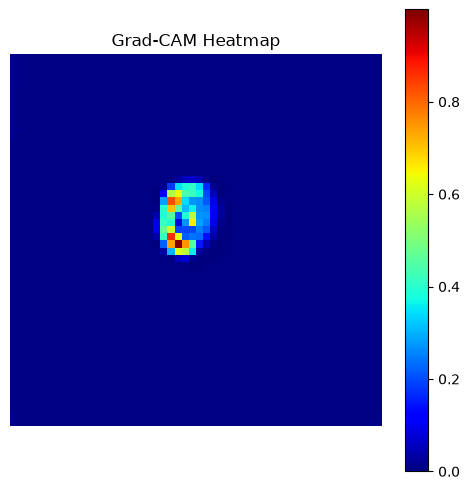

In [28]:
plt.figure(figsize=(6,6))

plt.imshow(
    heatmap,
    cmap="jet"
)

plt.colorbar()

plt.title("Grad-CAM Heatmap")

plt.axis("off")

plt.show()

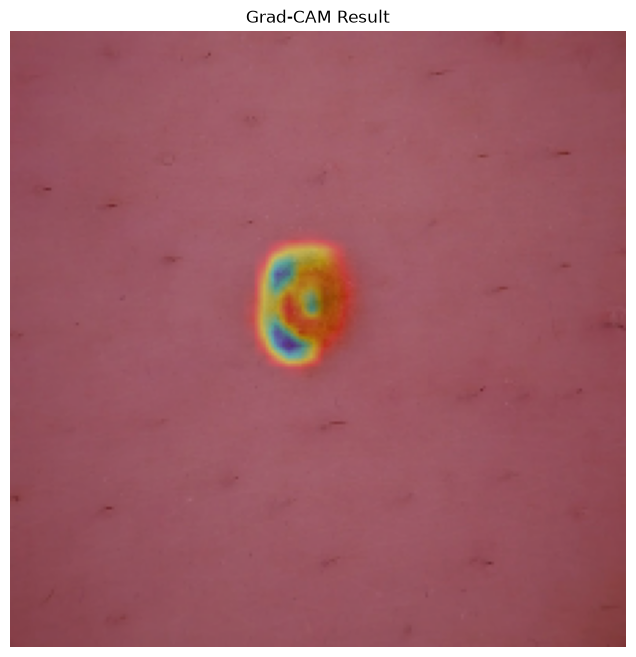

In [29]:
original = cv2.imread(image_path)

original = cv2.cvtColor(
    original,
    cv2.COLOR_BGR2RGB
)

original = cv2.resize(
    original,
    IMG_SIZE
)

heatmap = cv2.resize(
    heatmap,
    IMG_SIZE
)

heatmap = np.uint8(
    255 * heatmap
)

heatmap = cv2.applyColorMap(
    heatmap,
    cv2.COLORMAP_JET
)

superimposed = cv2.addWeighted(

    original,

    0.6,

    heatmap,

    0.4,

    0

)

plt.figure(figsize=(8,8))

plt.imshow(superimposed)

plt.title("Grad-CAM Result")

plt.axis("off")

plt.show()

In [30]:
predicted_class = class_names[np.argmax(prediction)]

confidence = np.max(prediction)

print("Predicted Disease :", predicted_class)

print("Confidence Score :", confidence)

Predicted Disease : mel
Confidence Score : 0.72344065


In [ ]:
print(best_model.built)

True


In [ ]:
best_model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │    22,151,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 66,739,415 (254.59 MB)

 Trainable params: 22,246,471 (84.86 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 44,492,944 (169.73 MB)

In [24]:
print(type(best_model))

print(best_model.built)

print(hasattr(best_model, "inputs"))
print(hasattr(best_model, "outputs"))

print(best_model.inputs)
print(best_model.outputs)

<class 'keras.src.models.sequential.Sequential'>
True
True
True
[<KerasTensor shape=(None, 224, 224, 3), dtype=float32, sparse=False, ragged=False, name=input_layer_5>]
[<KerasTensor shape=(None, 7), dtype=float32, sparse=False, ragged=False, name=keras_tensor_89>]


In [25]:
print(tf.__version__)
print(tf.keras.__version__)

2.21.0
3.15.1


# Saliency Map

In [ ]:
prediction = best_model.predict(image)

predicted_class = np.argmax(prediction)

print("Confidence :", np.max(prediction))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step
Confidence : 0.72344065


In [37]:
image_tensor = tf.convert_to_tensor(image)

with tf.GradientTape() as tape:

    tape.watch(image_tensor)

    predictions = best_model(image_tensor)

    loss = predictions[:, predicted_class]

gradients = tape.gradient(
    loss,
    image_tensor
)

saliency = tf.reduce_max(
    tf.abs(gradients),
    axis=-1
)

saliency = saliency.numpy()[0]

In [39]:
saliency = tf.reduce_max(
    tf.abs(gradients),
    axis=-1
)

saliency = saliency.numpy()[0]

saliency = (
    saliency - saliency.min()
) / (
    saliency.max() - saliency.min() + 1e-8
)

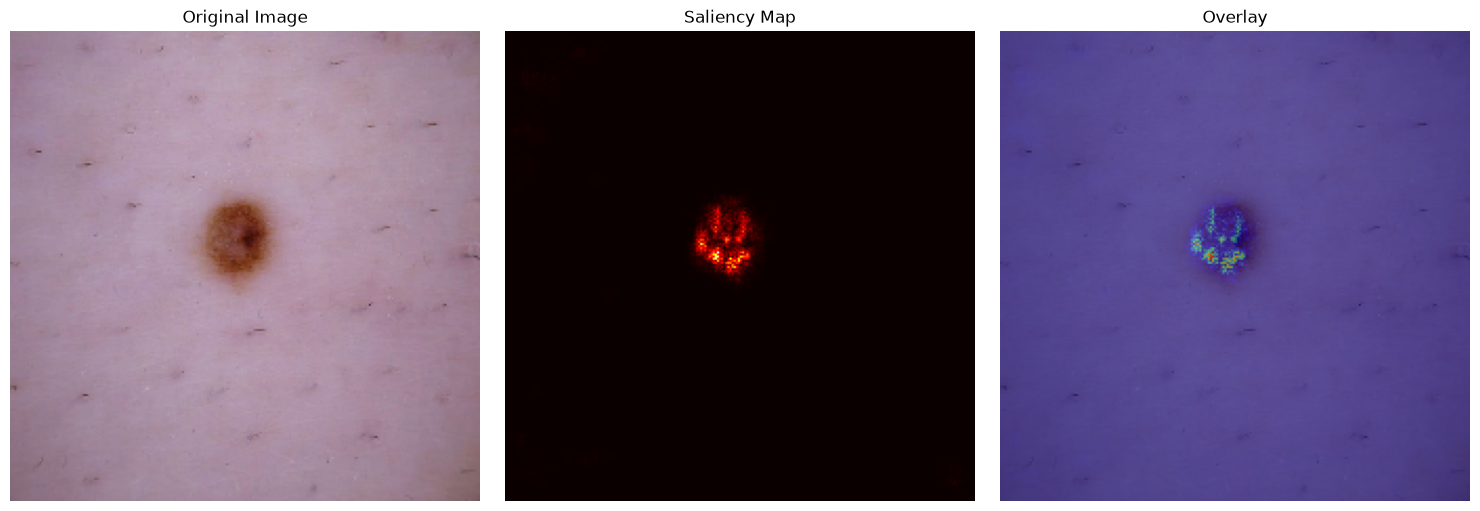

In [40]:
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)

plt.imshow(image[0])

plt.title("Original Image")

plt.axis("off")


plt.subplot(1,3,2)

plt.imshow(
    saliency,
    cmap="hot"
)

plt.title("Saliency Map")

plt.axis("off")


plt.subplot(1,3,3)

plt.imshow(image[0])

plt.imshow(
    saliency,
    cmap="jet",
    alpha=0.5
)

plt.title("Overlay")

plt.axis("off")

plt.tight_layout()

plt.show()